# 03 — Price the cash instruments

Calculate local-currency and INR values for bonds, equities and securitisation cash positions.

Cash instruments have direct market values. Foreign positions are first priced locally and then translated to INR, which also creates FX sensitivity.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns, display_sample,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260908T033903126517Z


This is the part of the calculation chain being handled here:

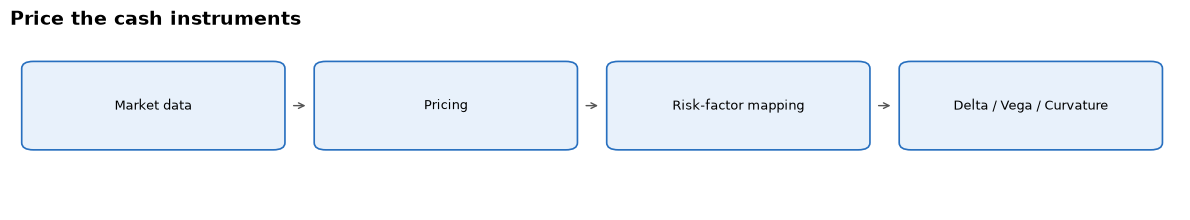

In [2]:
draw_flow(['Market data', 'Pricing', 'Risk-factor mapping', 'Delta / Vega / Curvature'],'Price the cash instruments',wrap_after=4)

The local pricing rule depends on the product. The final translation step is common to every foreign position.

$$V_{INR}=V_{local}\times FX_{local/INR}$$

In [3]:
values=pd.read_csv(RUN/'02_valuations.csv')
view=values[values.product_form=='cash'].copy()
view['calculated_inr']=view.market_value_local*view.fx_to_inr
columns=['trade_id','desk','instrument_type','currency','market_value_local','fx_to_inr','market_value_inr']
display(crore_table(view[columns],['market_value_inr']))
example=view[view.currency!='INR'].iloc[0]
print(f"Worked trade {example.trade_id}: {example.market_value_local:,.2f} {example.currency} x {example.fx_to_inr:,.4f} = INR {example.market_value_inr:,.2f}")

,trade_id,desk,instrument_type,currency,market_value_local,fx_to_inr,Market Value (INR crore)
0,R01,Rates,BOND,INR,"99,608,101.9050",1.0000,9.9608
1,R02,Rates,BOND,INR,"150,434,120.3849",1.0000,15.0434
2,R03,Rates,BOND,INR,"-120,472,041.0378",1.0000,-12.0472
3,R04,Rates,BOND,USD,"2,005,931.5793",86.2000,17.2911
4,R05,Rates,BOND,EUR,"1,762,399.4621",93.4000,16.4608
10,R11,Rates,INFLATION_BOND,INR,"93,568,978.2602",1.0000,9.3569
12,C01,Credit,CORPORATE_BOND,INR,"97,562,616.2163",1.0000,9.7563
13,C02,Credit,CORPORATE_BOND,USD,"1,445,713.9595",86.2000,12.4621
14,C03,Credit,CORPORATE_BOND,EUR,"1,200,349.4757",93.4000,11.2113
15,C04,Credit,CORPORATE_BOND,INR,"67,413,396.4690",1.0000,6.7413


Worked trade R04: 2,005,931.58 USD x 86.2000 = INR 172,911,302.14


The visual below uses the calculated rows shown above.

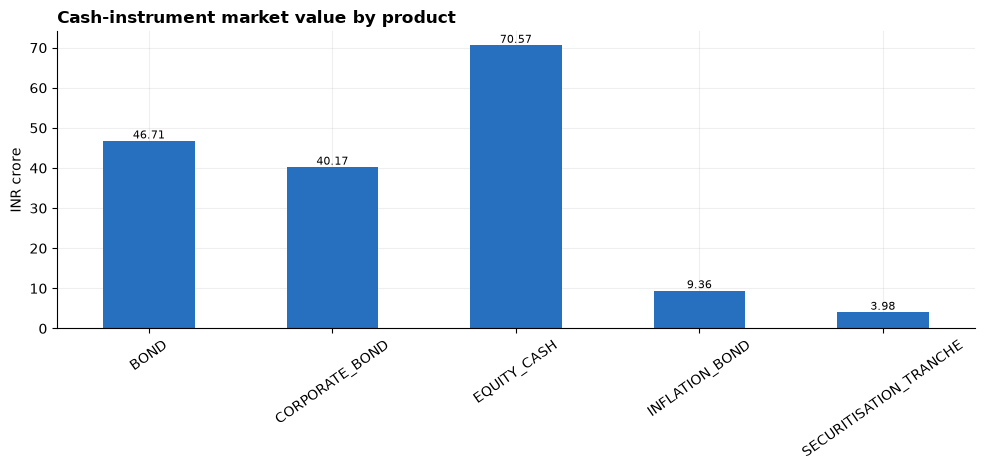

In [4]:
bar_crore(view.groupby('instrument_type')['market_value_inr'].sum(),'Cash-instrument market value by product')

Every cash instrument has a base INR value for the repricing calculations.